# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:

dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
N = 300

In [8]:
frank2d = Frank2D(N, rout)

In [9]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [10]:
uvtable_gridded = frank2d.gridded_data

In [11]:
vis_syn =  uvtable_gridded['vis'].reshape(N, N)
weights_syn = uvtable_gridded['weights'].reshape(N, N)
u_syn = uvtable_gridded['u'].reshape(N, N)
v_syn = uvtable_gridded['v'].reshape(N, N)

In [12]:
vis_syn.shape

(300, 300)

In [13]:
params_N50 = {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
params_N60 = {'m': -2.0009878605169256, 'c': 11330741611.726267, 'l': 168455.0566935454}
params_N70 = {'m': -1.8390199401929106, 'c': 49331965.595233, 'l': 13484.863460993764}
params_N80 =  {'m': -1.3296845423917079, 'c': 630250.8664425968, 'l': 17128.80592131163}

In [14]:
params_N50, params_N60, params_N70, params_N80, params_N100 = [{'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318}, {'m': -3.173339346404725, 'c': 4782311642990891.0, 'l': 83515.6290880256}, {'m': -3.5831562281230305, 'c': 1.473704358376612e+18, 'l': 81079.44744259916}, {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 68720.771036978}, {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}]

In [15]:
Qmax_N50, Qmax_N60, Qmax_N70, Qmax_N80, Qmax_N100 = [1823140.5402181398, 2187768.648261768, 2552396.756305396, 2917024.8643490244, 3646281.0804362795]

In [16]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
x1 = binned_vis.uv
y1 = np.abs(binned_vis.V)**2
logx = np.log10(x1)
logy = np.log10(y1)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
x2 = binned_vis2.uv
y2 = np.abs(binned_vis2.V)**2
logx2 = np.log10(x2)
logy2 = np.log10(y2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

def power_spectrum(x, m, c):
    return c*x**(m)

x = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)
lgx = np.log10(x)

y_N50 = power_spectrum(x, params_N50['m'], params_N50['c'])
y_N60 = power_spectrum(x, params_N60['m'], params_N60['c'])
y_N70 = power_spectrum(x, params_N70['m'], params_N70['c'])
y_N80 = power_spectrum(x, params_N80['m'], params_N80['c'])
y_N100 = power_spectrum(x, params_N100['m'], params_N100['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']


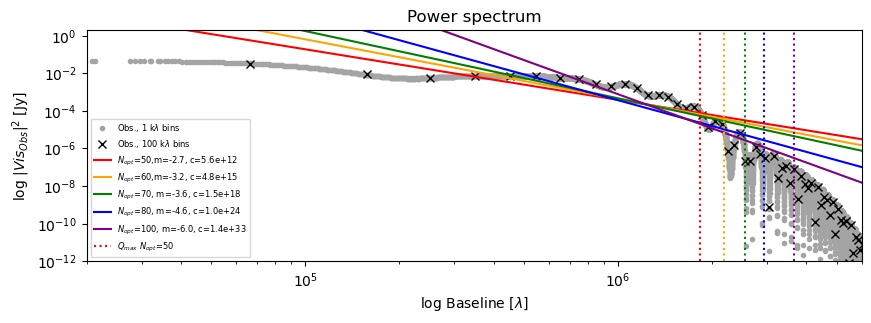

In [17]:

plt.figure(figsize=(10, 3))
plt.plot(x1, y1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x2, y2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.plot(x, y_N50, c = 'r', label=r'$N_{opt}$=50,'+ 'm={:.1f}, c={:.1e}'.format(params_N50['m'], params_N50['c']))
plt.plot(x, y_N60, c = 'orange', label=r'$N_{opt}$=60,'+ 'm={:.1f}, c={:.1e}'.format(params_N60['m'], params_N60['c']))
plt.plot(x, y_N70, c='g', label=r'$N_{opt}$=70,'+ ' m={:.1f}, c={:.1e}'.format(params_N70['m'], params_N70['c']))
plt.plot(x, y_N80, c='b', label=r'$N_{opt}$=80,'+ ' m={:.1f}, c={:.1e}'.format(params_N80['m'], params_N80['c']))
plt.plot(x, y_N100, c='purple', label=r'$N_{opt}$=100,'+ ' m={:.1f}, c={:.1e}'.format(params_N100['m'], params_N100['c']))

plt.axvline(Qmax_N50, color='r', ls=':', label=r'$Q_{max}$ $N_{opt}$=50')
plt.axvline(Qmax_N60, color='orange', ls=':')
plt.axvline(Qmax_N70, color='g', ls=':')
plt.axvline(Qmax_N80, color='b', ls=':')
plt.axvline(Qmax_N100, color='purple', ls=':')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'best', fontsize = 6)
plt.title("Power spectrum")
plt.ylim(1e-12, 2)
plt.xlim(2e4, 6e6)
plt.show()

### frank2d

In [18]:
geom = Geometry(0, 0, 0, 0)

In [19]:
N = 300
rout = 1*2

In [20]:
N_opt = [50, 60, 70, 80, 100]

In [21]:
maps = [params_N50, params_N60, params_N70, params_N80, params_N100]
frank2d_objects = []
times_opt =  [9.326814635594685, 16.271777180830636, 29.956044511000314, 62.58505432208379, 239.67634643713635] # min
times_best = [28.13317108154297, 32.60010886192322, 26.65605092048645, 19.283380031585693, 53.582895040512085] # seg
times_opt2 = []

In [23]:
for i in range(len(N_opt)):
    start_time = time.time()

    frank2d = Frank2D(N, rout)
    frank2d.process_vis(uvtable)
    initial_guess = {'m': -2, 'logl': 4}
    frank2d.search_MAP(initial_guess= initial_guess, N = N_opt[i]) #31m5.5s
    #frank2d.fit(uvtable, kernel_params=maps[i], rtol = 1e-10)

    end_time = time.time()
    total_time = end_time - start_time
    print("xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt={} : {:.2f} seconds".format(N_opt[i], total_time))

    times_opt2.append(total_time)
    frank2d_objects.append(frank2d)

===>  Setting gridded data...
Using existing visibility data...
!!!!!!!!! 1823140.5402181398
Fitting the visibilities with Frank2D with 2DFT...
  + Time to set up the matrices: 63.55 seconds
Setting the initial guess...
Optimizing the posterior...
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=50 : 570.16 seconds
===>  Setting gridded data...
Using existing visibility data...
!!!!!!!!! 2187768.648261768
Fitting the visibilities with Frank2D with 2DFT...
  + Time to set up the matrices: 168.27 seconds
Setting the initial guess...
Optimizing the posterior...
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=60 : 987.09 seconds
===>  Setting gridded data...
Using existing visibility data...
!!!!!!!!! 2552396.756305396
Fitting the visibilities with Frank2D with 2DFT...
  + Time to set up the matrices: 377.69 seconds
Setting the initial guess...
Optimizing the posterior...
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=70 : 1816.33 seconds
===>  Setting gridded data...
Using existing visibility data...

### frank2d with best values

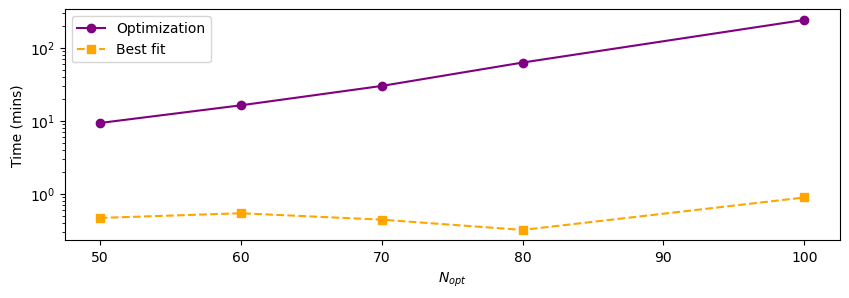

In [61]:
plt.figure(figsize=(10, 3))
plt.plot(N_opt, np.array(times), 'o-', color='purple', label='Optimization')
plt.plot(N_opt, np.array(times_best)/60, 's--', color='orange', label='Best fit')
plt.xlabel(r'$N_{opt}$')
plt.ylabel("Time (mins)")
plt.yscale('log')
plt.legend()
plt.show()

In [62]:
maps

[{'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318},
 {'m': -3.173339346404725, 'c': 4782311642990891.0, 'l': 83515.6290880256},
 {'m': -3.5831562281230305,
  'c': 1.473704358376612e+18,
  'l': 81079.44744259916},
 {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 68720.771036978},
 {'m': -6.0445769086881205,
  'c': 1.4300593860064604e+33,
  'l': 80200.56804261949}]

### Plot the stats for posterior

#### function to plot

In [63]:
def plot_MAP_estimation_results(results, results_best, N_opt, normalize = False):
    ms = results['ms']
    cs = results['cs']
    ls = results['ls']
    jDjs = results['jDjs']
    logdetDs = results['logdetDs']
    logdetSs = results['logdetSs']
    minus_log_posteriors = results['minus_log_posteriors']

    m_best = results_best['m']
    c_best = 10**results_best['logc']
    l_best = 10**results_best['logl']
    jDj_best = results_best['jDj']
    logdetD_best = results_best['logdetD']
    logdetS_best = results_best['logdetS']
    minus_log_posterior_best = results_best['minus_log_posterior']

    fig, axs = plt.subplots(3, 3, figsize=(10, 7))
    axs = axs.ravel()

    iterations = np.arange(1, len(ms) + 1)

    axs[0].plot(iterations, ms, '-', c='purple')
    axs[0].set_xlabel('Iteration')
    axs[0].axhline(  m_best, color='gray', linestyle='--',
                        label=r'$m_{best}$ =' + f'{m_best:.2e}')
    axs[0].set_ylabel('m')
    axs[0].legend(fontsize=7, loc='best')

    axs[1].plot(iterations, cs, '-', c='purple')
    axs[1].set_xlabel('Iteration')
    axs[1].axhline( c_best, color='gray', linestyle='--',
                       label=r'$c_{best}$ =' + f'{c_best:.2e}')
    axs[1].set_yscale('log')
    axs[1].set_ylabel('logc')
    axs[1].legend(fontsize=7, loc='best')

    axs[2].plot(iterations, ls, '-', c='purple')
    axs[2].set_xlabel('Iteration')
    axs[2].axhline(  l_best, color='gray', linestyle='--',
                         label=r'$l_{best}$ =' + f'{l_best:.2e}')
    axs[2].set_yscale('log')
    axs[2].set_ylabel('logl')
    axs[2].legend(fontsize=7, loc='best')

    axs[3].plot(iterations, jDjs, '-', c='red')
    if normalize:
        jDjs = np.abs(jDjs - jDj_best)
        axs[3].set_ylabel(r'$\|jDj- jDj_{best}\|$')
    else:
        axs[3].axhline( jDj_best, color='gray', linestyle='--',
                         label=r'$jDj_{best}$ =' + f'{jDj_best:.2e}')
        axs[3].set_ylabel('jDj')
        axs[3].legend(fontsize=7, loc='best')
    axs[3].set_xlabel('Iteration')

    axs[4].plot(iterations, logdetDs, '-', c='blue')
    axs[4].set_xlabel('Iteration')
    if normalize:
        logdetDs = np.abs(logdetDs - logdetD_best)
        axs[4].set_ylabel(r'$\|log|D| - log|D|_{best}\|$')
    else:
        axs[4].axhline(
            logdetD_best, color='gray', linestyle='--',
            label=r'$log|D|_{best}$ =' + f'{logdetD_best:.2e}')
        axs[4].legend(fontsize=7, loc='best')
        axs[4].set_ylabel('log|D|')

    axs[5].plot(iterations, logdetSs, '-', c='green')
    axs[5].set_xlabel('Iteration')
    if normalize:
        logdetSs = np.abs(logdetSs-logdetS_best)
        axs[5].set_ylabel(r'$\| log|S| - log|S|_{best}\|$')
    else:
        axs[5].axhline(  logdetS_best, color='gray', linestyle='--',
                         label=r'$log|S|_{best}$ =' + f'{logdetS_best:.2e}')
        axs[5].set_ylabel('log|S|')
        axs[5].legend(fontsize=7, loc='best')

    axs[7].plot(iterations, minus_log_posteriors, '-', c='black')
    axs[7].set_xlabel('Iteration')
    if normalize:
        minus_log_posteriors = np.abs(minus_log_posteriors - minus_log_posterior_best)
        axs[7].set_ylabel(r'$\|logP -logP_{best}\|$')
    else:
        axs[7].axhline(  minus_log_posterior_best, color='gray', linestyle='--',
                         label= r'$-logP_{best}$ =' + f'{minus_log_posterior_best:.2e}')
        axs[7].set_ylabel('-logP')
        axs[7].legend(fontsize=7, loc='best')

    for ax in [axs[6], axs[8]]:
        fig.delaxes(ax)

    plt.suptitle(r'MAP Estimation $N_{opt}$ ='+ str(N_opt))
    plt.tight_layout()
    plt.show()

#### example with N50

In [66]:
frank2d_N50 = frank2d_objects[0]

In [69]:
MAPEs_N50 = frank2d_N50.MAPEstimator

In [97]:
best_N50 = {
    'm': frank2d_N50.MAP['m'], 
    'logc': np.log10(frank2d_N50.MAP['c']),
    'logl': np.log10(frank2d_N50.MAP['l'])
}


In [74]:
ms_N50 =  MAPEs_N50._ms
cs_N50 = MAPEs_N50._cs
ls_N50 = MAPEs_N50._ls
jDjs_N50 = MAPEs_N50._jDjs
logdetDs_N50 = MAPEs_N50._logdetDs
logdetSs_N50 = MAPEs_N50._logdetSs
minus_log_posteriors_N50 = MAPEs_N50._minus_log_posteriors

In [96]:
GP_N50 =  MAPEs_N50.GaussianModel


In [98]:
best_minus_log_posteriors_N50 = GP_N50.minus_log_posterior(best_N50)

In [99]:
best_jDj_N50, best_logdetD_N50, best_logdetS_N50 = GP_N50.jDj, GP_N50.logdetD, GP_N50.logdetS

In [118]:
results_N50 = {
    'ms': ms_N50,
    'cs': cs_N50,
    'ls': ls_N50,
    'jDjs': jDjs_N50,
    'logdetDs': logdetDs_N50,
    'logdetSs': logdetSs_N50,
    'minus_log_posteriors': minus_log_posteriors_N50
}

In [119]:
results_best_N50 = {
    'm': best_N50['m'],
    'logc': best_N50['logc'],
    'logl': best_N50['logl'],
    'jDj': best_jDj_N50,
    'logdetD': best_logdetD_N50,
    'logdetS': best_logdetS_N50,
    'minus_log_posteriors': best_minus_log_posteriors_N50
}

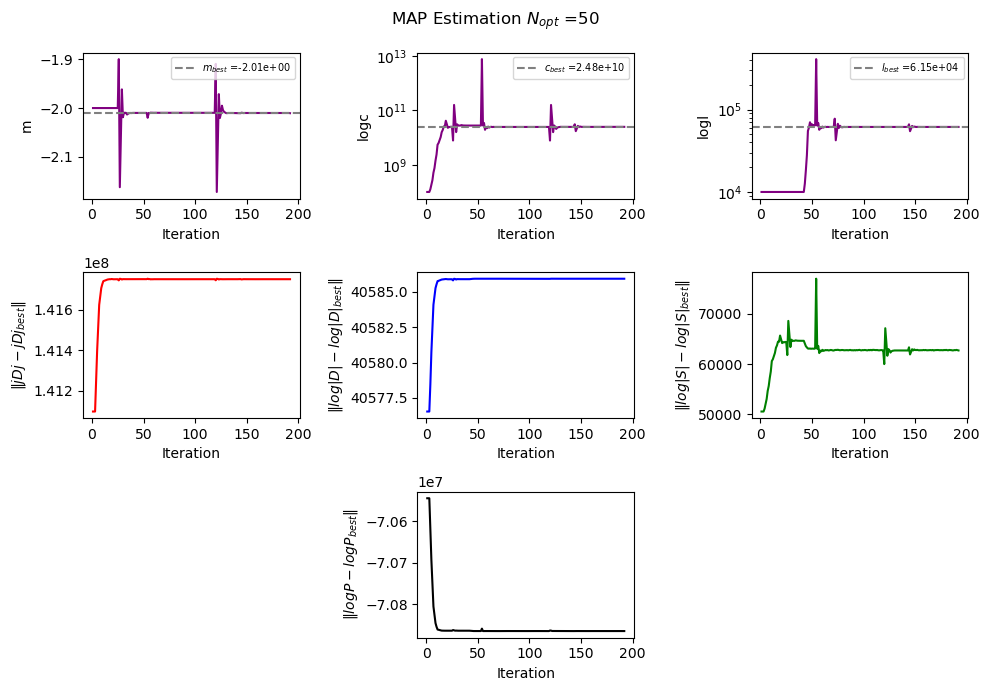

In [209]:
plot_MAP_estimation_results(results_N50, results_best_N50, 50, normalize = True) 

#### run them all

In [64]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator

    MAP_N = frank2d_N.MAP
    m_best_N = MAP_N['m']
    l_best_N = MAP_N['l']
    c_best_N = MAP_N['c']
    logl_best_N = np.log10(l_best_N)
    logc_best_N = np.log10(c_best_N)
    best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N
    }

    ms_N =  MAPEs_N._ms
    cs_N = MAPEs_N._cs
    ls_N = MAPEs_N._ls
    jDjs_N = MAPEs_N._jDjs
    logdetDs_N = MAPEs_N._logdetDs
    logdetSs_N = MAPEs_N._logdetSs
    minus_log_posteriors_N = MAPEs_N._minus_log_posteriors

    results_N = {
        'ms': ms_N,
        'cs': cs_N,
        'ls': ls_N,
        'jDjs': jDjs_N,
        'logdetDs': logdetDs_N,
        'logdetSs': logdetSs_N,
        'minus_log_posteriors': minus_log_posteriors_N,
    }

    GP_N =  MAPEs_N.GaussianModel

    best_minus_log_posteriors_N = GP_N.minus_log_posterior(best_N)
    best_jDj_N, best_logdetD_N, best_logdetS_N = GP_N.jDj, GP_N.logdetD, GP_N.logdetS
    
    results_best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N,
        'minus_log_posterior': best_minus_log_posteriors_N,
        'jDj': best_jDj_N,
        'logdetD': best_logdetD_N,
        'logdetS': best_logdetS_N,
    }

    plot_MAP_estimation_results(results_N, results_best_N, N_opt[i], normalize = False) 


AttributeError: 'Frank2D' object has no attribute '_MAP_estimator'

### Maximum baseline for each N_opt

In [232]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator
    GP_N =  MAPEs_N.GaussianModel
    DFT_N = GP_N._2DFT
    print( DFT_N._Xmax)


2.0
2.0
2.0
2.0


## Plot the best

In [ ]:
for i in range(len(frank2d_objects)):
    start = time.time()
    frank2d = Frank2D(N, rout, geom)
    maps_i = maps[i]
    frank2d.fit(data = uvtable, kernel_params = maps_i, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times.append(total_time)
    frank2d_objects.append(frank2d)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={maps_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")


In [76]:
for i in range(len(frank2d_objects)):
    Plot_ = Plot(frank2d_objects[i])
    Plot_.intensity( vmax=1e10,  gamma = 1, zoom=1,
                     title= r'$I_{model}^{frank2d}$ for N_opt = ' + str(N_opt[i]))
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for N_opt = ' + str(N_opt[i]))